In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
# Parameter windowing
input_width = int(48)*1
label_width = 48
shift = label_width
total_window_size = input_width + shift
OUT_STEPS = label_width
# Definisikan irisan untuk input dan label
input_slice = slice(0, input_width)
label_start = total_window_size - label_width
labels_slice = slice(label_start, None)

from C_template import  scale_array, inverse_scale_array,  process_predictions, compute_metrics, compute_error, make_multi_input_windows, make_windows_autoregressive

# data training

In [2]:
data_training_awal= pd.read_excel('D:\satwika_bintang\CODE\TIMESERIES-master\C_train_data.xlsx', index_col=0)
data_training= data_training_awal.astype('float32').copy()
data_training

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2022-01-02 00:00:00,17928.000000,0.000000,1.000000,-0.781832,0.623490,0.0,1.000000e+00,1.012018,-3.938439
2022-01-02 00:30:00,17506.000000,0.130526,0.991445,-0.781832,0.623490,0.0,1.000000e+00,1.012018,-4.090625
2022-01-02 01:00:00,17293.000000,0.258819,0.965926,-0.781832,0.623490,0.0,1.000000e+00,1.012018,-4.242810
2022-01-02 01:30:00,17108.000000,0.382683,0.923880,-0.781832,0.623490,0.0,1.000000e+00,1.012018,-4.406652
2022-01-02 02:00:00,16876.000000,0.500000,0.866025,-0.781832,0.623490,0.0,1.000000e+00,1.012018,-4.570495
...,...,...,...,...,...,...,...,...,...
2024-10-30 21:30:00,29717.320312,-0.608761,0.793353,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,0.843025
2024-10-30 22:00:00,29019.070312,-0.500000,0.866025,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,0.447690
2024-10-30 22:30:00,28465.740234,-0.382683,0.923880,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,0.134316


In [3]:
data_training.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,49584.000000,4.958400e+04,4.958400e+04,49584.000000,49584.000000,4.958400e+04,4.958400e+04,49584.000000,49584.000000
mean,24940.107422,0.000000e+00,2.442656e-09,0.000944,0.001960,3.792538e-02,-4.566980e-02,1.000763,-0.296778
std,3034.502441,7.071139e-01,7.071139e-01,0.707232,0.706993,7.060961e-01,7.056375e-01,0.046631,4.279876
min,13475.000000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,0.697430,-10.782065
25%,22708.074707,-7.071068e-01,-7.071068e-01,-0.781832,-0.900969,-5.000000e-01,-8.660254e-01,1.012018,-3.767801
50%,24938.290039,6.123234e-17,-6.123234e-17,0.000000,-0.222521,1.224647e-16,-1.836970e-16,1.012018,-1.267493
75%,27242.814941,7.071068e-01,7.071068e-01,0.781832,0.623490,8.660254e-01,5.000000e-01,1.012018,2.887948
max,32758.619141,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,1.012018,13.803565


In [4]:
data_training['Suhu_PCA'], min_suhu, max_suhu = scale_array(
    data_training['Suhu_PCA'].values, 
    new_min=-1,
    new_max=1)

data_training['Holiday_Impact'], min_holiday, max_holiday = scale_array(
    data_training['Holiday_Impact'].values, 
    new_min=-1, 
    new_max=1
)

data_training['Beban'], min_beban, max_beban = scale_array(
    data_training['Beban'].values, 
    new_min=-1, 
    new_max=1)

Computed orig_min: -10.782065391540527
Computed orig_max: 13.80356502532959
Computed orig_min: 0.6974297761917114
Computed orig_max: 1.0120183229446411
Computed orig_min: 13475.0
Computed orig_max: 32758.619140625


In [5]:
data_training.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,49584.000000,4.958400e+04,4.958400e+04,49584.000000,49584.000000,4.958400e+04,4.958400e+04,49584.000000,49584.000000
mean,0.189103,0.000000e+00,2.442656e-09,0.000944,0.001960,3.792538e-02,-4.566980e-02,0.928443,-0.147039
std,0.314723,7.071139e-01,7.071139e-01,0.707232,0.706993,7.060961e-01,7.056375e-01,0.296460,0.348161
min,-1.000000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,-1.000000,-1.000000
25%,-0.042392,-7.071068e-01,-7.071068e-01,-0.781832,-0.900969,-5.000000e-01,-8.660254e-01,1.000000,-0.429401
50%,0.188915,6.123234e-17,-6.123234e-17,0.000000,-0.222521,1.224647e-16,-1.836970e-16,1.000000,-0.226005
75%,0.427929,7.071068e-01,7.071068e-01,0.781832,0.623490,8.660254e-01,5.000000e-01,1.000000,0.112033
max,1.000000,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000


# data validation (testing)

In [6]:
data_validation_awal= pd.read_excel('D:\satwika_bintang\CODE\TIMESERIES-master\C_test_data.xlsx', index_col=0)
data_validation= data_validation_awal.astype('float32').copy()
data_validation

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2024-10-31 00:00:00,26757.400391,0.000000,1.000000,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-0.625510
2024-10-31 00:30:00,26460.919922,0.130526,0.991445,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-0.829108
2024-10-31 01:00:00,26184.929688,0.258819,0.965926,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-1.032705
2024-10-31 01:30:00,25976.689453,0.382683,0.923880,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-1.284443
2024-10-31 02:00:00,25745.220703,0.500000,0.866025,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-1.536183
...,...,...,...,...,...,...,...,...,...
2025-10-29 21:30:00,29000.099609,-0.608761,0.793353,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,-1.283128
2025-10-29 22:00:00,28302.843750,-0.500000,0.866025,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,-1.492234
2025-10-29 22:30:00,27757.216797,-0.382683,0.923880,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,-1.727889


In [7]:
data_validation['Suhu_PCA'], _, _ = scale_array(
    data_validation['Suhu_PCA'].values,
    new_min=-1,
    new_max=1,
    orig_min=min_suhu,
    orig_max=max_suhu
)
data_validation['Holiday_Impact'], _, _ = scale_array(
    data_validation['Holiday_Impact'].values,
    new_min=-1,
    new_max=1,
    orig_min=min_holiday,
    orig_max=max_holiday
)
data_validation['Beban'], _, _ = scale_array(
    data_validation['Beban'].values, 
    new_min=-1, 
    new_max=1,
    orig_min=min_beban,
    orig_max=max_beban
)

In [8]:
data_validation.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,17472.000000,1.747200e+04,1.747200e+04,1.747200e+04,1.747200e+04,17472.000000,1.747200e+04,17472.000000,17472.000000
mean,0.389521,5.458301e-11,2.265195e-09,-2.488985e-08,8.733282e-09,-0.000736,-4.758367e-03,0.927457,-0.054006
std,0.317072,7.071270e-01,7.071270e-01,7.071270e-01,7.071270e-01,0.706155,7.080817e-01,0.295316,0.311923
min,-0.775485,-1.000000e+00,-1.000000e+00,-9.749279e-01,-9.009688e-01,-1.000000,-1.000000e+00,-1.000000,-0.847113
25%,0.158794,-7.071068e-01,-7.071068e-01,-7.818315e-01,-9.009688e-01,-0.500000,-8.660254e-01,1.000000,-0.310480
50%,0.385354,6.123234e-17,-6.123234e-17,0.000000e+00,-2.225209e-01,0.000000,-1.836970e-16,1.000000,-0.118824
75%,0.668933,7.071068e-01,7.071068e-01,7.818315e-01,6.234898e-01,0.866025,5.000000e-01,1.000000,0.207680
max,1.139628,1.000000e+00,1.000000e+00,9.749279e-01,1.000000e+00,1.000000,1.000000e+00,1.000000,0.836694


# training model

In [9]:
input_make_windows      =   data_training.to_numpy()
output_make_windows     =   data_training['Beban'].to_numpy()
periodic_indices = data_training.columns.get_indexer(['Jam_sin','Jam_cos', 'Hari_sin', 'Hari_cos', 'Bulan_sin', 'Bulan_cos'])
    
x_train, x_train_periodic, y_train = make_multi_input_windows(input_make_windows,
                                                         output_make_windows,
                                                         total_window_size=total_window_size, 
                                                         input_slice=input_slice,
                                                         labels_slice=labels_slice, 
                                                         periodic_indices=periodic_indices)

In [10]:
input_make_windows_validation   = data_validation.to_numpy()
output_make_windows_validation  = data_validation['Beban'].to_numpy()
x_val, x_val_periodic, y_val                   = make_multi_input_windows(input_make_windows_validation, 
                                                           output_make_windows_validation,
                                                           total_window_size=total_window_size,
                                                             input_slice=input_slice, 
                                                             labels_slice=labels_slice,
                                                             periodic_indices=periodic_indices)

In [11]:
x_train.shape, y_train.shape,  x_train_periodic.shape, x_val.shape, y_val.shape,  x_val_periodic.shape,

((49489, 48, 9),
 (49489, 48),
 (49489, 48, 6),
 (17377, 48, 9),
 (17377, 48),
 (17377, 48, 6))

In [12]:
x_train.dtype, y_train.dtype, x_train_periodic.dtype, x_val.dtype, y_val.dtype, x_val_periodic.dtype, 

(dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'))

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, ReLU, BatchNormalization, Dropout, Add, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model
import time
import json
from tensorflow.keras.callbacks import History, ModelCheckpoint, EarlyStopping

def build_model_tensor(input_lag, num_features, forecast_horizon, periodic_features):
    
# Branch 1: MS-CNN for History 
    input_history = Input(shape=(input_lag, num_features), name='historical_input')
    
    # Initial convolutions based on the architectural diagram
    x = Conv1D(filters=64, kernel_size=8, padding='same', dilation_rate=1)(input_history)
    x = Conv1D(filters=24, kernel_size=8, padding='same', dilation_rate=1)(x)

    # 8 Residual Blocks with multi-scale convolutions
    for block in range(8):
        for s in [1, 2, 4]:
            res = x 
            
            # The dilation rate 's' scales up within each block
            x = Conv1D(filters=24, kernel_size=8, padding='same', dilation_rate=s)(x)
            x = ReLU()(x)
            x = BatchNormalization()(x)
            x = Dropout(0.05)(x)
            
            x = Add()([res, x])
            
    cnn_out = Flatten()(x)

    # Branch 2: Fully Connected Subnetwork for Future Periodic Coding
    input_periodic = Input(shape=(forecast_horizon, periodic_features), name='periodic_input')
    x2 = Flatten()(input_periodic)
    
    # The paper shows multiple dense layers for the time cognition branch
    x2 = Dense(64, activation='relu')(x2)
    periodic_out = Dense(32, activation='relu')(x2)

    # Fusion Layer: Combine spatial features with future time cognition
    merged = Concatenate()([cnn_out, periodic_out])
    merged = Dense(128, activation='relu')(merged)
    
    # Output: Load forecast for the targeted horizon
    final_output = Dense(forecast_horizon, name='forecast_output')(merged)

    model = Model(inputs=[input_history, input_periodic], outputs=final_output)
    return model

In [14]:
def tensorflow_model(X_train_scaled, Y_train_scaled,
                     X_val_scaled,   Y_val_scaled,
                     learning_rate=1e-3,
                     target_MAE=0.001,
                     jumlah_epochs=50,
                     jumlah_sampel_batch=32, 
                     jumlah_epoch_terbelakang=10,
                     save_best_model_path="model.h5",
                     validation_data=False,
                     load_model=None, seed_value=-1):

    # Removing global variables for safer execution
    loss_history = {}

    # ---------- callbacks ----------
    class MAEStop(tf.keras.callbacks.Callback):
        def __init__(self, thr): super().__init__(); self.thr = thr
        def on_epoch_end(self, epoch, logs=None):
            if logs and logs.get('mae', 1e9) < self.thr:
                print(f"\nMAE < {self.thr}. Stop."); self.model.stop_training = True

    class SaveEveryNEpoch(tf.keras.callbacks.Callback):
        def __init__(self, n, root): super().__init__(); self.n, self.root = n, root
        def on_epoch_end(self, epoch, logs=None):
            if (epoch + 1) % self.n == 0:
                fname = f"{self.root}_epoch{epoch+1:02d}.h5"
                self.model.save(fname)
                print(f"\n📦  Saved checkpoint: {fname}")

    class LiveLossLogger(tf.keras.callbacks.Callback):
        def __init__(self, filename, use_validation):
            super().__init__()
            self.filename = filename
            self.use_validation = use_validation
            self.live_history = {'loss': []}
            if self.use_validation:
                self.live_history['val_loss'] = []

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            
            current_loss = logs.get('loss')
            if current_loss is not None:
                self.live_history['loss'].append(float(current_loss))
            
            if self.use_validation:
                current_val_loss = logs.get('val_loss') 
                if current_val_loss is not None:
                    self.live_history['val_loss'].append(float(current_val_loss))
            
            with open(self.filename, 'w') as f:
                json.dump(self.live_history, f)

    history_cb = History()

    # ---------- model ----------
    # X_train_scaled is now a list [X_history, X_periodic]
    # We must extract the shapes from the specific array indices
    input_width  = X_train_scaled[0].shape[1]   
    num_features = X_train_scaled[0].shape[2]   
    periodic_feats = X_train_scaled[1].shape[2]
    forecast_horizon = Y_train_scaled.shape[1]
    
    if load_model is None:
        model = build_model_tensor(input_width, num_features, forecast_horizon, periodic_feats)
    else:
        model = tf.keras.models.load_model(load_model)

    model.summary()
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                  loss='mse',
                  metrics=['mse', 'mae',
                           tf.keras.metrics.MeanAbsolutePercentageError(name='mape')]
                           ,  steps_per_execution=500)

    # ---------- build callback list ----------
    json_filename = f"loss_history_{save_best_model_path}.json"
    
    cb = [
        history_cb,
        MAEStop(target_MAE),
        SaveEveryNEpoch(10, root=save_best_model_path.rstrip('.h5')),
        LiveLossLogger(json_filename, validation_data)
    ]

    if validation_data:
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_mse',    
            factor=0.5,           
            patience=4,           
            min_lr=1e-6,          
            verbose=1             
        )
        
        cb += [
            lr_scheduler,
            ModelCheckpoint(save_best_model_path,
                            monitor='val_mse', mode='min',
                            save_best_only=True, verbose=1),
            EarlyStopping(monitor='val_mse', mode='min',
                          patience=jumlah_epoch_terbelakang,
                          restore_best_weights=True, verbose=1)
        ]
    else:
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='mse',        
            factor=0.3,
            patience=8,
            min_lr=1e-6,
            verbose=1
        )
        
        cb += [
            lr_scheduler,
            ModelCheckpoint(save_best_model_path,
                            monitor='mse', mode='min',
                            save_best_only=True, verbose=1),
            EarlyStopping(monitor='mse', mode='min',
                          patience=jumlah_epoch_terbelakang,
                          restore_best_weights=True, verbose=1)
        ]

    # ---------- training with exception handling ----------
    start = time.time()
    
    # Prepare validation tuple safely
    val_tuple = (X_val_scaled, Y_val_scaled) if validation_data else None

    try:
        model.fit(X_train_scaled, Y_train_scaled,
                  epochs=jumlah_epochs,
                  batch_size=jumlah_sampel_batch,
                  shuffle=False,
                  validation_data=val_tuple,
                  callbacks=cb,
                  verbose=True)
    except Exception as e:
        print("Training stopped with error:", e)
    finally:
        try:
            with open(json_filename, 'r') as f:
                loss_history = json.load(f)
        except FileNotFoundError:
            loss_history = {}
        print(f"Final training and validation loss securely saved to {json_filename}")

    print("Train time (s):", time.time() - start)

    # ---------- evaluate ----------
    loss, mse, mae, mape = model.evaluate(X_train_scaled, Y_train_scaled, verbose=0)
    print(f"Train  Loss={loss:.5f}  MSE={mse:.5f}  MAE={mae:.5f}  MAPE={mape:.3f}%")
    return model, loss, mse, mae, mape, loss_history

In [15]:

seed_vektor= [20]
for seed_value in seed_vektor:
    print(f"Running with seed: {seed_value}")
    tf.random.set_seed(seed_value)
    save_best_model_path = "TCMS_%s.h5"%seed_value
    model,     loss, MSE, MAE, MAPE, loss_history  = tensorflow_model(
        X_train_scaled=[x_train, x_train_periodic], Y_train_scaled=y_train, X_val_scaled=[x_val, x_val_periodic], Y_val_scaled=y_val, learning_rate=0.01, target_MAE=0.0001,  jumlah_epochs=100, jumlah_sampel_batch=64, 
                                                    jumlah_epoch_terbelakang=20,  save_best_model_path = save_best_model_path, 
                                                    validation_data=True, load_model=None, seed_value=seed_value)
    print(loss, MSE, MAE, MAPE)


Running with seed: 20
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 historical_input (InputLayer)  [(None, 48, 9)]      0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 48, 64)       4672        ['historical_input[0][0]']       
                                                                                                  
 conv1d_1 (Conv1D)              (None, 48, 24)       12312       ['conv1d[0][0]']                 
                                                                                                  
 conv1d_2 (Conv1D)              (None, 48, 24)       4632        ['conv1d_1[0][0]']               
                                                                        

Loading best model from:  TCMS_20.h5
544/544 [==============================] - 2s 4ms/step - loss: 12.2215 - mse: 12.2215 - mae: 0.5796 - mape: 1322.8715
model.evaluate(x_val, y_val):  [12.221519470214844, 12.221519470214844, 0.5796417593955994, 1322.8714599609375]
33/33 [==============================] - 0s 4ms/step
before dropna
                         Prediksi        Aktual
Date                                           
2022-01-03 00:00:00  12249.765625  19210.000000
2022-01-03 00:30:00  11869.041016  19023.000000
2022-01-03 01:00:00  10323.678711  18850.000000
2022-01-03 01:30:00  15346.208008  18607.000000
2022-01-03 02:00:00  15320.355469  18430.000000
...                           ...           ...
2024-10-30 21:30:00  13589.211914  29717.320312
2024-10-30 22:00:00  11645.875000  29019.070312
2024-10-30 22:30:00  13155.744141  28465.740234
2024-10-30 23:00:00  14185.664062  27755.750000
2024-10-30 23:30:00  15243.770508  27277.500000

[49536 rows x 2 columns]
after dropna
   

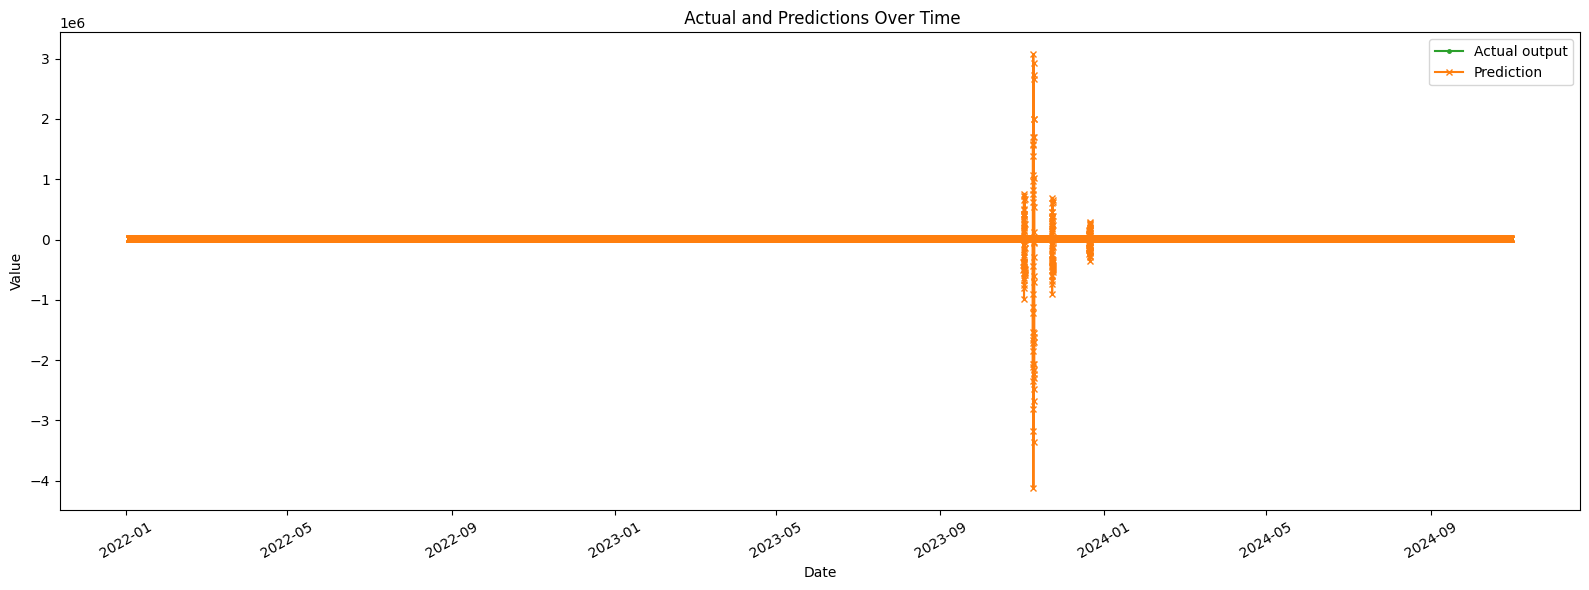

12/12 [==============================] - 0s 5ms/step
before dropna
                         Prediksi        Aktual
Date                                           
2024-11-01 00:00:00  12249.765625  26764.179688
2024-11-01 00:30:00  11869.041016  26442.910156
2024-11-01 01:00:00  10323.678711  26127.140625
2024-11-01 01:30:00  15346.208008  26032.009766
2024-11-01 02:00:00  15320.355469  25634.070312
...                           ...           ...
2025-10-29 21:30:00  13589.211914  29000.099609
2025-10-29 22:00:00  11645.875000  28302.843750
2025-10-29 22:30:00  13155.744141  27757.216797
2025-10-29 23:00:00  14185.664062  27084.208984
2025-10-29 23:30:00  15243.770508  26643.658203

[17424 rows x 2 columns]
after dropna
                         Prediksi        Aktual
Date                                           
2024-11-01 00:00:00  12249.765625  26764.179688
2024-11-01 00:30:00  11869.041016  26442.910156
2024-11-01 01:00:00  10323.678711  26127.140625
2024-11-01 01:30:00  15346.208

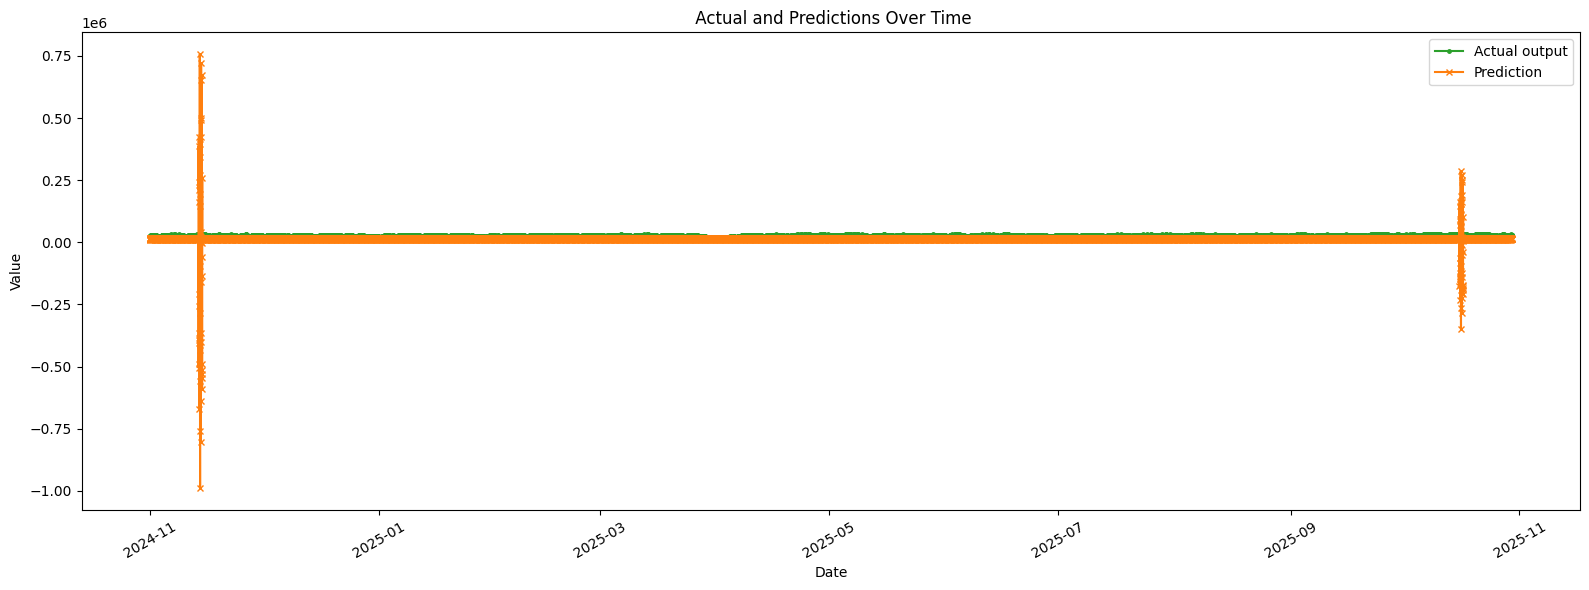

In [16]:
save_best_model_path
model.load_weights(save_best_model_path)
print("Loading best model from: ", save_best_model_path)
print("model.evaluate(x_val, y_val): ", model.evaluate([x_val, x_val_periodic], y_val))
predictions = model.predict([x_train[slice(None, None, label_width), :, :], x_train_periodic[slice(None, None, label_width), :, :]] )
predictions_reshaped = predictions.reshape(-1,)
predictions_unscaled = inverse_scale_array(predictions_reshaped, orig_min=min_beban, orig_max=max_beban)
df_pred_act = compute_error([x_train, x_train_periodic], 
                            data_training_awal['Beban'], ['Beban'], model, input_width,label_width, min_beban, max_beban)
print(df_pred_act)
df= df_pred_act.copy()
plt.figure(figsize=(16, 6))

# Plot the "Actual" as a green line with dot markers
plt.plot(
    df.index, 
    df['Aktual'], 
    label='Actual output', 
    marker='.', 
    markersize=5, 
    color='#2ca02c', 
    zorder=-100
)

# Scatter plot for "Prediction" in orange X markers
plt.plot(
    df.index, 
    df['Prediksi'], 
    marker='x', 
    markersize=5, 
    #edgecolors='k', 
    label='Prediction', 
    c='#ff7f0e', 
    #s=15
)

plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=30)
plt.title(' Actual and Predictions Over Time')
plt.tight_layout()
plt.show()







df_pred_act = compute_error([x_val, x_val_periodic], data_validation_awal['Beban'], ['Beban'], model, input_width,label_width, min_beban, max_beban)
print(df_pred_act)

df= df_pred_act.copy()
plt.figure(figsize=(16, 6))

# Plot the "Actual" as a green line with dot markers
plt.plot(
    df.index, 
    df['Aktual'], 
    label='Actual output', 
    marker='.', 
    markersize=5, 
    color='#2ca02c', 
    zorder=-100
)

# Scatter plot for "Prediction" in orange X markers
plt.plot(
    df.index, 
    df['Prediksi'], 
    marker='x', 
    markersize=5, 
    #edgecolors='k', 
    label='Prediction', 
    c='#ff7f0e', 
    #s=15
)

plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=30)
plt.title(' Actual and Predictions Over Time')
plt.tight_layout()
plt.show()